In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(12)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
5,1000,2023-08,0,3,0,5400,3,5400,2023-03,2023-12,СПб,44.0,female
6,1000,2023-09,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
7,1000,2023-11,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
8,1000,2023-12,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female


In [3]:
grouped_df = df.groupby(['id_user']).agg(all_indiv = ('cnt_indiv', 'sum'), all_total = ('cnt_total', 'sum')).reset_index()
grouped_df['percent_indiv'] = grouped_df['all_indiv'] / grouped_df['all_total'] * 100
grouped_df['flag_70'] = np.where(grouped_df['percent_indiv'] > 70, 1, 0)
grouped_df

,id_user,all_indiv,all_total,percent_indiv,flag_70
0,1000,33,33,100.000000,1
1,1001,23,129,17.829457,0
2,1002,64,128,50.000000,0
3,1004,18,18,100.000000,1
4,1005,7,7,100.000000,1
...,...,...,...,...,...
833,1992,12,39,30.769231,0
834,1993,2,24,8.333333,0
835,1994,0,7,0.000000,0
836,1995,0,23,0.000000,0


In [4]:
list_70 = grouped_df[grouped_df['flag_70'] == 1]['id_user'].tolist()

In [5]:
df[df['id_user'].isin(list_70)].groupby(['city']).agg(mean_check = ('sum_total', 'mean'), mean_count = ('cnt_total', 'mean')).reset_index()
#Наибольший средний чек и среднее количество тренировок - у жителей Казани

,city,mean_check,mean_count
0,Екатеринбург,5727.927928,3.207207
1,Казань,6021.917808,3.465753
2,Москва,5991.666667,3.373563
3,СПб,5763.562753,3.230769


In [6]:
df[df['id_user'].isin(list_70)].groupby(['gender']).agg(mean_check = ('sum_total', 'mean'), mean_count = ('cnt_total', 'mean')).reset_index()
#В среднем у мужчин больше количество тренировок в неделю и средний чек

,gender,mean_check,mean_count
0,female,5841.812865,3.293860
1,male,6034.762980,3.390519


In [7]:
top10 = grouped_df.sort_values(['all_total'], ascending = False)['id_user'].head(10).tolist()
top10

[1381, 1013, 1657, 1506, 1929, 1570, 1001, 1002, 1194, 1582]

In [8]:
top10_df = df[df['id_user'].isin(top10)]
top10_unique = top10_df[['id_user', 'city', 'gender']].drop_duplicates()
top10_unique

,id_user,city,gender
9,1001,Москва,female
20,1002,Москва,male
76,1013,Москва,male
990,1194,СПб,female
1805,1381,Москва,female
2368,1506,Москва,female
2686,1570,Екатеринбург,male
2751,1582,Екатеринбург,male
3093,1657,СПб,male
4299,1929,Москва,male


In [9]:
city_dist = top10_unique['city'].value_counts()
city_dist

city
Москва          6
СПб             2
Екатеринбург    2
Name: count, dtype: int64

In [10]:
gender_dist = top10_unique['gender'].value_counts()
gender_dist

gender
male      6
female    4
Name: count, dtype: int64

In [11]:
min_max = df[['id_user', 'min_mon', 'max_mon']].drop_duplicates()
min_max

,id_user,min_mon,max_mon
0,1000,2023-03,2023-12
9,1001,2023-01,2023-12
20,1002,2023-02,2023-12
31,1004,2023-02,2023-10
40,1005,2023-07,2023-10
...,...,...,...
4573,1992,2023-01,2023-10
4577,1993,2023-08,2023-09
4579,1994,2023-10,2023-10
4580,1995,2023-06,2023-11


In [12]:
new_clients = min_max.groupby('min_mon')['id_user'].nunique().reset_index().rename(columns = {'min_mon':'month', 'id_user':'new_count'})
new_clients

,month,new_count
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57
5,2023-06,51
6,2023-07,48
7,2023-08,35
8,2023-09,28
9,2023-10,27


In [13]:
gone_clients = min_max.groupby('max_mon')['id_user'].nunique().reset_index().rename(columns = {'max_mon':'month', 'id_user':'gone_count'})
#убираем последний месяц, так как в противном случае это создаст ложное представление о том, что на нём все ушли
gone_clients = gone_clients[gone_clients['month'] != '2023-12'] 
gone_clients

,month,gone_count
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21
5,2023-06,13
6,2023-07,33
7,2023-08,33
8,2023-09,55
9,2023-10,101


In [14]:
active_clients = df.groupby('mon')['id_user'].nunique().reset_index().rename(columns = {'mon':'month', 'id_user':'active_count'})
active_clients

,month,active_count
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360
5,2023-06,383
6,2023-07,412
7,2023-08,423
8,2023-09,429
9,2023-10,441


In [15]:
result = active_clients.merge(new_clients, on='month', how='inner')
result = result.merge(gone_clients, on='month', how='left')
result

,month,active_count,new_count,gone_count
0,2023-01,337,337,15.0
1,2023-02,350,88,22.0
2,2023-03,355,83,37.0
3,2023-04,345,62,21.0
4,2023-05,360,57,21.0
5,2023-06,383,51,13.0
6,2023-07,412,48,33.0
7,2023-08,423,35,33.0
8,2023-09,429,28,55.0
9,2023-10,441,27,101.0


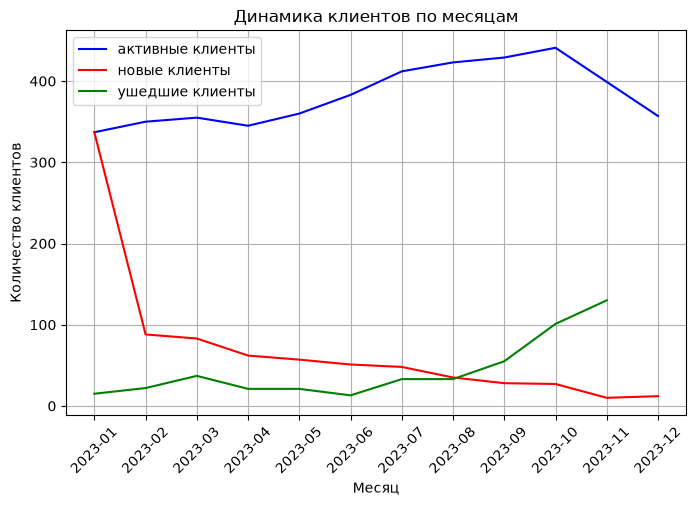

In [16]:
plt.figure(figsize = (8,5))
plt.plot(result['month'], result['active_count'], c = 'b', label = 'активные клиенты')
plt.plot(result['month'], result['new_count'], c = 'r', label = 'новые клиенты')
plt.plot(result['month'], result['gone_count'], c = 'g', label = 'ушедшие клиенты')
plt.title('Динамика клиентов по месяцам')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.ylabel('Количество клиентов')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()